In [1]:
import uproot
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import ROOT
import awkward as ak
from yaml import safe_load
from math import sqrt

Welcome to JupyROOT 6.28/10


In [2]:
# Config and yaml file must be in this directory by default
# Absolute path must be supplied for the script to work in batch mode
configPath =  "/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/"
sys.path.append(os.path.abspath(configPath))
import config as cfg

In [3]:
# Read list of feature names used in the BDT from the config YAML file
with open(cfg.fccana_opts['yamlPath']) as stream:
    yaml = safe_load(stream)
    BDThbranchList = yaml['BDTh-vars']

In [4]:
folder_path = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/no_selection/'
#list = ['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu','p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu','p8_ee_Zbb_ecm91','p8_ee_Zcc_ecm91','p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91']
list = cfg.samples

sample = 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu'
file_path = folder_path + f"{sample}/chunk_0.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open( file_path )

tree = uproot_file['events']

# define variables we want out
branches = BDThbranchList
branches.append("EVT_Thrust_x")
branches.append("EVT_Thrust_y")
branches.append("EVT_Thrust_z")
branches.append("EVT_hemisEmin_nLept")




df_Bs_chunk0 = tree.arrays(
    expressions = branches, 
    library = 'pd' ,
)
    
# close file
uproot_file.close()

In [5]:
sample = 'p8_ee_Zbb_ecm91'
file_path = folder_path + f"{sample}/chunk_0.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open(file_path )

tree = uproot_file['events']


df_bb= tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)
    

# close file
uproot_file.close()



In [6]:
sample = 'p8_ee_Zud_ecm91'
file_path = folder_path + f"{sample}/chunk_0.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open(file_path )

tree = uproot_file['events']

df_ud = tree.arrays(
    expressions = branches, 
    library = 'pd' ,
)
    

    
# close file
uproot_file.close()



In [7]:
sample = 'p8_ee_Zcc_ecm91'
file_path = folder_path + f"{sample}/chunk_0.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open(file_path )

tree = uproot_file['events']

df_cc = tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)
    

    
# close file
uproot_file.close()



In [8]:
sample = 'p8_ee_Zss_ecm91'
file_path = folder_path + f"{sample}/chunk_0.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open(file_path )

tree = uproot_file['events']

df_ss = tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)
    

    
# close file
uproot_file.close()



## Energy 2d plots

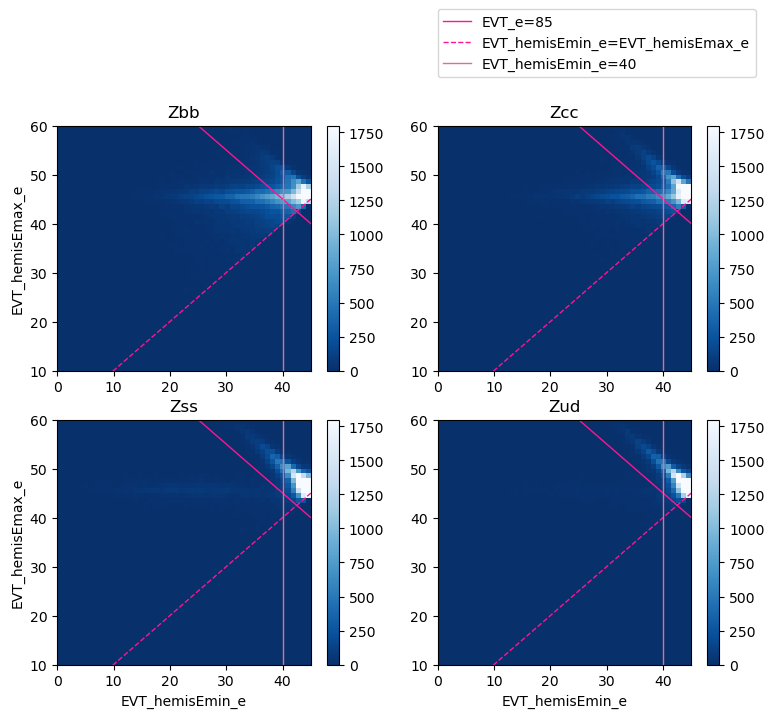

In [9]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('EVT_hemisEmax_e')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_hemisEmin_e')
axs[1,0].set_ylabel('EVT_hemisEmax_e')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_hemisEmin_e')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb["EVT_hemisEmin_e"], df_bb["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=1800)
h2 = axs[0, 1].hist2d(df_cc["EVT_hemisEmin_e"], df_cc["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=1800)
h3 = axs[1, 0].hist2d(df_ss["EVT_hemisEmin_e"], df_ss["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=1800)
h4 = axs[1, 1].hist2d(df_ud["EVT_hemisEmin_e"], df_ud["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=1800)

# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])

# Line to plot
x_line = np.linspace(0,45, 100)
y_line = 85 - x_line 

axs[0,0].plot(x_line, y_line, color='deeppink', linewidth=1,label='EVT_e=85')
axs[0,1].plot(x_line, y_line, color='deeppink', linewidth=1)
axs[1,0].plot(x_line, y_line, color='deeppink', linewidth=1)
axs[1,1].plot(x_line, y_line,color='deeppink', linewidth=1)


y2 = x_line
axs[0,0].plot(x_line, y2, '--',color='deeppink', linewidth=1,label='EVT_hemisEmin_e=EVT_hemisEmax_e')
axs[0,1].plot(x_line, y2, '--',color='deeppink', linewidth=1)
axs[1,0].plot(x_line, y2, '--',color='deeppink', linewidth=1)
axs[1,1].plot(x_line, y2, '--',color='deeppink', linewidth=1)


y3 = np.linspace(10,60, 100)
x3 = 40*np.ones(100)
axs[0,0].plot(x3, y3 ,color='palevioletred', linewidth=1,label='EVT_hemisEmin_e=40')
axs[0,1].plot(x3, y3,color='palevioletred', linewidth=1)
axs[1,0].plot(x3, y3,color='palevioletred', linewidth=1)
axs[1,1].plot(x3, y3,color='palevioletred', linewidth=1)



axs[0,0].legend(loc=(1.5,1.2))
plt.show()



In [11]:
#fig.savefig('Energy_cut_heatmaps_bkgs.pdf')

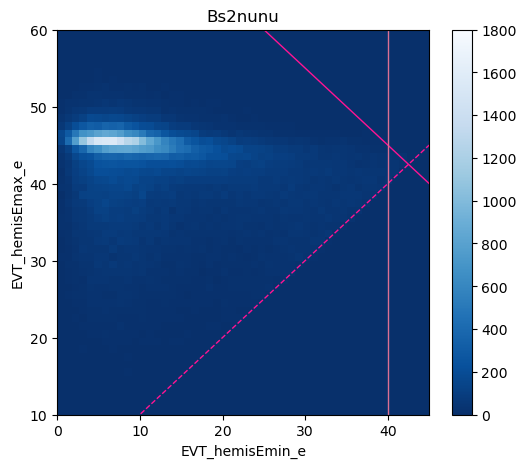

In [16]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

# Big bins
h=axs.hist2d(df_Bs_chunk0["EVT_hemisEmin_e"], df_Bs_chunk0["EVT_hemisEmax_e"], bins=(50, 50), range=[[0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=1800)
axs.set_title('Bs2nunu')
axs.set_ylabel('EVT_hemisEmax_e')
axs.set_xlabel('EVT_hemisEmin_e')


axs.plot(x_line, y_line, color='deeppink', linewidth=1)
axs.plot(x_line, y2, '--',color='deeppink', linewidth=1)
axs.plot(x3, y3,color='palevioletred', linewidth=1)


# Visualizing colorbar 
fig.colorbar(h[3], ax=axs)
plt.show()

In [15]:
#fig.savefig('Energy_cut_heatmaps_bssignal_washedout_nocuts.pdf')

### With EVT_hemisEmin_nlept ==0 cut

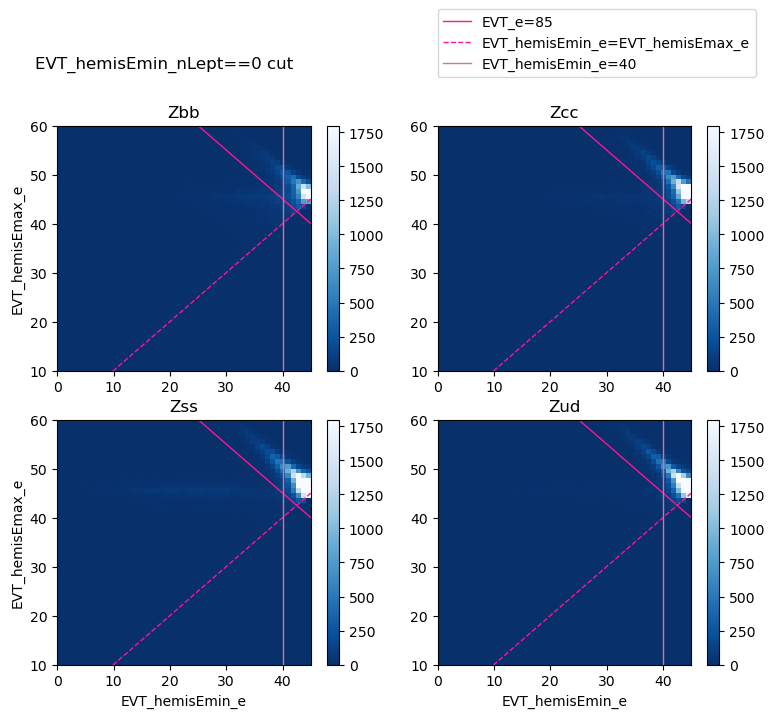

In [14]:
df_bb_nleptcut = df_bb[df_bb["EVT_hemisEmin_nLept"]==0]
df_cc_nleptcut = df_cc[df_cc["EVT_hemisEmin_nLept"]==0]
df_ss_nleptcut = df_ss[df_ss["EVT_hemisEmin_nLept"]==0]
df_ud_nleptcut = df_ud[df_ud["EVT_hemisEmin_nLept"]==0]



fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('EVT_hemisEmax_e')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_hemisEmin_e')
axs[1,0].set_ylabel('EVT_hemisEmax_e')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_hemisEmin_e')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb_nleptcut["EVT_hemisEmin_e"], df_bb_nleptcut["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=1800)
h2 = axs[0, 1].hist2d(df_cc_nleptcut["EVT_hemisEmin_e"], df_cc_nleptcut["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=1800)
h3 = axs[1, 0].hist2d(df_ss_nleptcut["EVT_hemisEmin_e"], df_ss_nleptcut["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=1800)
h4 = axs[1, 1].hist2d(df_ud_nleptcut["EVT_hemisEmin_e"], df_ud_nleptcut["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=1800)

# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])

# Line to plot
x_line = np.linspace(0,45, 100)
y_line = 85 - x_line 

axs[0,0].plot(x_line, y_line, color='deeppink', linewidth=1,label='EVT_e=85')
axs[0,1].plot(x_line, y_line, color='deeppink', linewidth=1)
axs[1,0].plot(x_line, y_line, color='deeppink', linewidth=1)
axs[1,1].plot(x_line, y_line,color='deeppink', linewidth=1)


y2 = x_line
axs[0,0].plot(x_line, y2, '--',color='deeppink', linewidth=1,label='EVT_hemisEmin_e=EVT_hemisEmax_e')
axs[0,1].plot(x_line, y2, '--',color='deeppink', linewidth=1)
axs[1,0].plot(x_line, y2, '--',color='deeppink', linewidth=1)
axs[1,1].plot(x_line, y2, '--',color='deeppink', linewidth=1)


y3 = np.linspace(10,60, 100)
x3 = 40*np.ones(100)
axs[0,0].plot(x3, y3 ,color='palevioletred', linewidth=1,label='EVT_hemisEmin_e=40')
axs[0,1].plot(x3, y3,color='palevioletred', linewidth=1)
axs[1,0].plot(x3, y3,color='palevioletred', linewidth=1)
axs[1,1].plot(x3, y3,color='palevioletred', linewidth=1)



axs[0,0].legend(loc=(1.5,1.2))
plt.suptitle('EVT_hemisEmin_nLept==0 cut',x=0.1, ha='left')
plt.show()



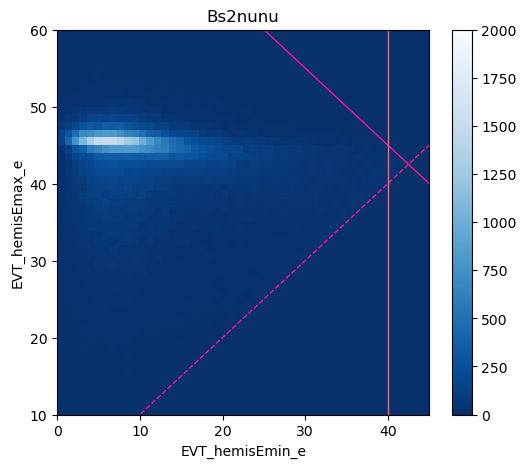

In [15]:
df_Bs_chunk0_nleptcut = df_Bs_chunk0[df_Bs_chunk0["EVT_hemisEmin_nLept"]==0]

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

# Big bins
h=axs.hist2d(df_Bs_chunk0_nleptcut["EVT_hemisEmin_e"], df_Bs_chunk0_nleptcut["EVT_hemisEmax_e"], bins=(50, 50), range=[[0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=2000)
axs.set_title('Bs2nunu')
axs.set_ylabel('EVT_hemisEmax_e')
axs.set_xlabel('EVT_hemisEmin_e')


axs.plot(x_line, y_line, color='deeppink', linewidth=1)
axs.plot(x_line, y2, '--',color='deeppink', linewidth=1)
axs.plot(x3, y3,color='palevioletred', linewidth=1)


# Visualizing colorbar 
fig.colorbar(h[3], ax=axs)
plt.show()

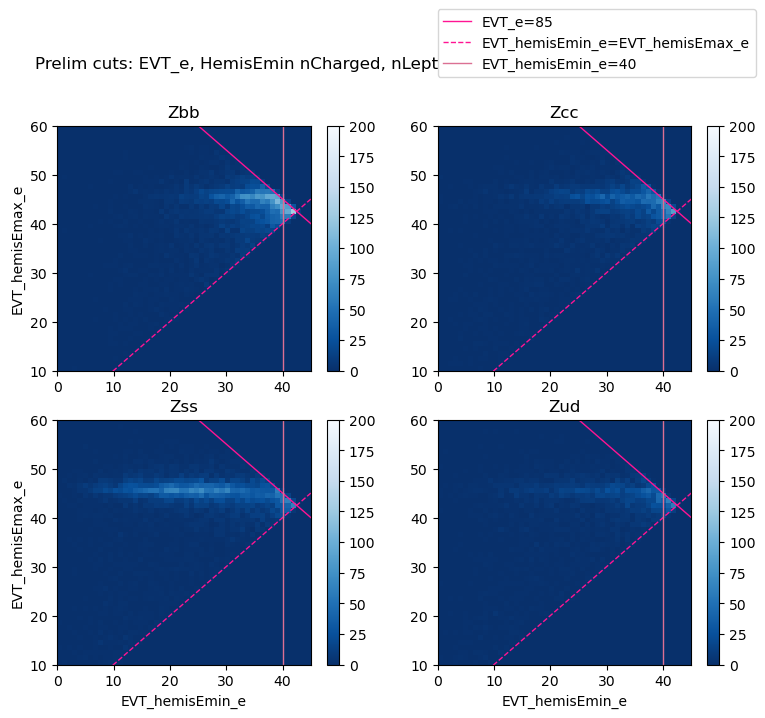

In [16]:
df_bb_fullcut = df_bb[(df_bb["EVT_hemisEmin_nLept"]==0)&(df_bb["EVT_e"]<85)&(df_bb["EVT_hemisEmin_nCharged"]>0)]
df_cc_fullcut = df_cc[(df_cc["EVT_hemisEmin_nLept"]==0)&(df_cc["EVT_e"]<85)&(df_cc["EVT_hemisEmin_nCharged"]>0)]
df_ss_fullcut = df_ss[(df_ss["EVT_hemisEmin_nLept"]==0)&(df_ss["EVT_e"]<85)&(df_ss["EVT_hemisEmin_nCharged"]>0)]
df_ud_fullcut = df_ud[(df_ud["EVT_hemisEmin_nLept"]==0)&(df_ud["EVT_e"]<85)&(df_ud["EVT_hemisEmin_nCharged"]>0)]



fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('EVT_hemisEmax_e')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_hemisEmin_e')
axs[1,0].set_ylabel('EVT_hemisEmax_e')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_hemisEmin_e')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb_fullcut["EVT_hemisEmin_e"], df_bb_fullcut["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=200)
h2 = axs[0, 1].hist2d(df_cc_fullcut["EVT_hemisEmin_e"], df_cc_fullcut["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=200)
h3 = axs[1, 0].hist2d(df_ss_fullcut["EVT_hemisEmin_e"], df_ss_fullcut["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=200)
h4 = axs[1, 1].hist2d(df_ud_fullcut["EVT_hemisEmin_e"], df_ud_fullcut["EVT_hemisEmax_e"], bins=(50, 50), range=[ [0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=200)

# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])

# Line to plot
x_line = np.linspace(0,45, 100)
y_line = 85 - x_line 

axs[0,0].plot(x_line, y_line, color='deeppink', linewidth=1,label='EVT_e=85')
axs[0,1].plot(x_line, y_line, color='deeppink', linewidth=1)
axs[1,0].plot(x_line, y_line, color='deeppink', linewidth=1)
axs[1,1].plot(x_line, y_line,color='deeppink', linewidth=1)


y2 = x_line
axs[0,0].plot(x_line, y2, '--',color='deeppink', linewidth=1,label='EVT_hemisEmin_e=EVT_hemisEmax_e')
axs[0,1].plot(x_line, y2, '--',color='deeppink', linewidth=1)
axs[1,0].plot(x_line, y2, '--',color='deeppink', linewidth=1)
axs[1,1].plot(x_line, y2, '--',color='deeppink', linewidth=1)


y3 = np.linspace(10,60, 100)
x3 = 40*np.ones(100)
axs[0,0].plot(x3, y3 ,color='palevioletred', linewidth=1,label='EVT_hemisEmin_e=40')
axs[0,1].plot(x3, y3,color='palevioletred', linewidth=1)
axs[1,0].plot(x3, y3,color='palevioletred', linewidth=1)
axs[1,1].plot(x3, y3,color='palevioletred', linewidth=1)



axs[0,0].legend(loc=(1.5,1.2))
plt.suptitle('Prelim cuts: EVT_e, HemisEmin nCharged, nLept',x=0.1, ha='left')
plt.show()



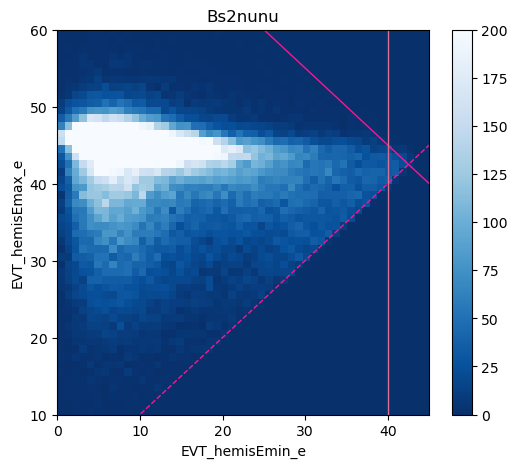

In [26]:
df_Bs_fullcut = df_Bs_chunk0[(df_Bs_chunk0["EVT_hemisEmin_nLept"]==0)&(df_Bs_chunk0["EVT_e"]<85)&(df_Bs_chunk0["EVT_hemisEmin_nCharged"]>0)]
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

# Big bins
h=axs.hist2d(df_Bs_chunk0_nleptcut["EVT_hemisEmin_e"], df_Bs_chunk0_nleptcut["EVT_hemisEmax_e"], bins=(50, 50), range=[[0, 45],[10, 60]], cmap=plt.cm.Blues_r,vmin=0,vmax=200)
axs.set_title('Bs2nunu')
axs.set_ylabel('EVT_hemisEmax_e')
axs.set_xlabel('EVT_hemisEmin_e')


axs.plot(x_line, y_line, color='deeppink', linewidth=1)
axs.plot(x_line, y2, '--',color='deeppink', linewidth=1)
axs.plot(x3, y3,color='palevioletred', linewidth=1)


# Visualizing colorbar 
fig.colorbar(h[3], ax=axs)
plt.show()

## Rec_thrust_cosTheta

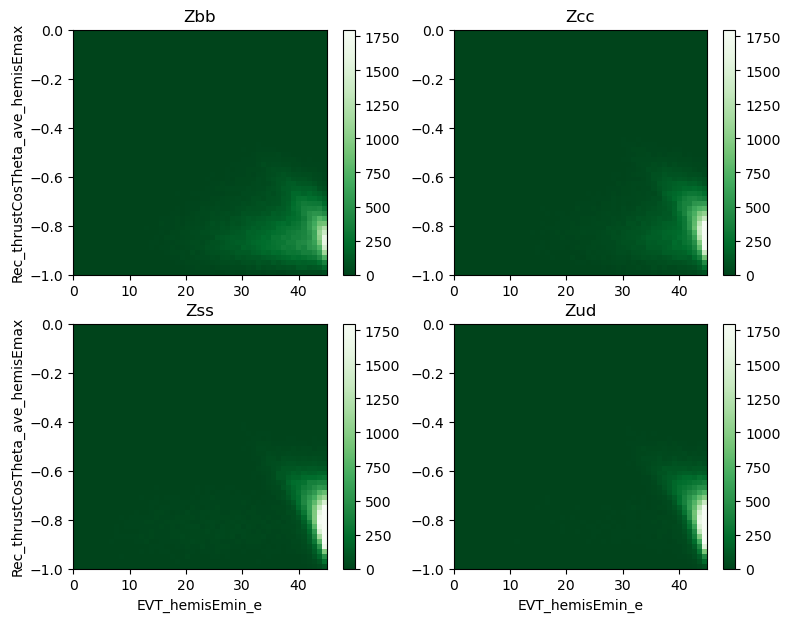

In [24]:

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('Rec_thrustCosTheta_ave_hemisEmax')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_hemisEmin_e')
axs[1,0].set_ylabel('Rec_thrustCosTheta_ave_hemisEmax')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_hemisEmin_e')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb["EVT_hemisEmin_e"], df_bb["Rec_thrustCosTheta_ave_hemisEmax"], bins=(50, 50), range=[ [0, 45],[-1, 0]], cmap=plt.cm.Greens_r,vmin=0,vmax=1800)
h2 = axs[0, 1].hist2d(df_cc["EVT_hemisEmin_e"], df_cc["Rec_thrustCosTheta_ave_hemisEmax"], bins=(50, 50), range=[ [0, 45],[-1, 0]], cmap=plt.cm.Greens_r,vmin=0,vmax=1800)
h3 = axs[1, 0].hist2d(df_ss["EVT_hemisEmin_e"], df_ss["Rec_thrustCosTheta_ave_hemisEmax"], bins=(50, 50), range=[ [0, 45],[-1, 0]], cmap=plt.cm.Greens_r,vmin=0,vmax=1800)
h4 = axs[1, 1].hist2d(df_ud["EVT_hemisEmin_e"], df_ud["Rec_thrustCosTheta_ave_hemisEmax"], bins=(50, 50), range=[ [0, 45],[-1, 0]], cmap=plt.cm.Greens_r,vmin=0,vmax=1800)

# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])


plt.show()



In [25]:
df_bb_rm = df_bb[df_bb["EVT_e"]>=85]
df_cc_rm = df_cc[df_cc["EVT_e"]>=85]
df_ss_rm = df_ss[df_ss["EVT_e"]>=85]
df_ud_rm = df_ud[df_ud["EVT_e"]>=85]


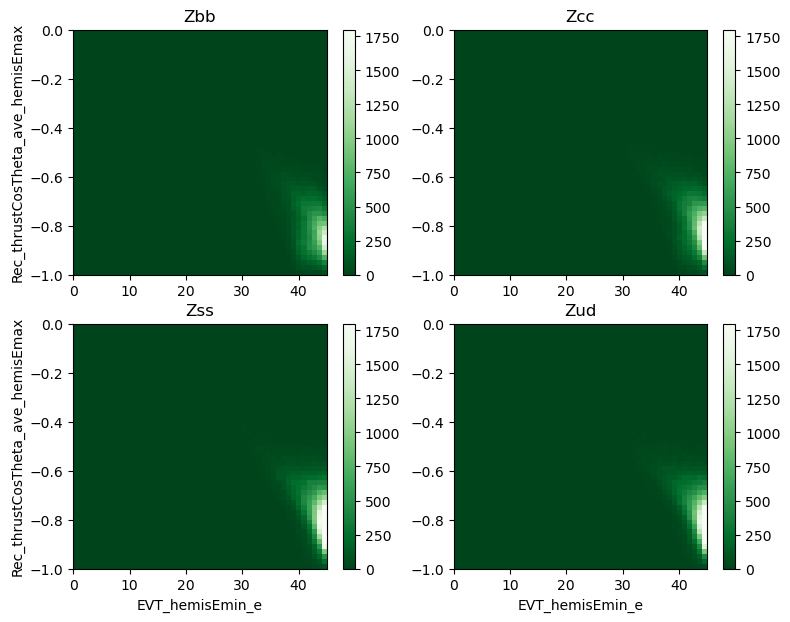

In [26]:

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('Rec_thrustCosTheta_ave_hemisEmax')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_hemisEmin_e')
axs[1,0].set_ylabel('Rec_thrustCosTheta_ave_hemisEmax')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_hemisEmin_e')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb_rm["EVT_hemisEmin_e"], df_bb_rm["Rec_thrustCosTheta_ave_hemisEmax"], bins=(50, 50), range=[ [0, 45],[-1, 0]], cmap=plt.cm.Greens_r,vmin=0,vmax=1800)
h2 = axs[0, 1].hist2d(df_cc_rm["EVT_hemisEmin_e"], df_cc_rm["Rec_thrustCosTheta_ave_hemisEmax"], bins=(50, 50), range=[ [0, 45],[-1, 0]], cmap=plt.cm.Greens_r,vmin=0,vmax=1800)
h3 = axs[1, 0].hist2d(df_ss_rm["EVT_hemisEmin_e"], df_ss_rm["Rec_thrustCosTheta_ave_hemisEmax"], bins=(50, 50), range=[ [0, 45],[-1, 0]], cmap=plt.cm.Greens_r,vmin=0,vmax=1800)
h4 = axs[1, 1].hist2d(df_ud_rm["EVT_hemisEmin_e"], df_ud_rm["Rec_thrustCosTheta_ave_hemisEmax"], bins=(50, 50), range=[ [0, 45],[-1, 0]], cmap=plt.cm.Greens_r,vmin=0,vmax=1800)

# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])


plt.show()



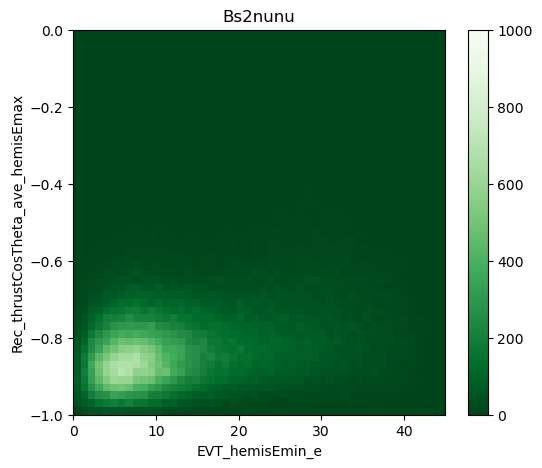

In [28]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

# Big bins
h=axs.hist2d(df_Bs_chunk0["EVT_hemisEmin_e"], df_Bs_chunk0["Rec_thrustCosTheta_ave_hemisEmax"], bins=(50, 50), range=[[0, 45],[-1, 0]], cmap=plt.cm.Greens_r,vmin=0,vmax=1000)
axs.set_title('Bs2nunu')
axs.set_ylabel('Rec_thrustCosTheta_ave_hemisEmax')
axs.set_xlabel('EVT_hemisEmin_e')

# Visualizing colorbar 
fig.colorbar(h[3], ax=axs)
plt.show()

## Thrust_z

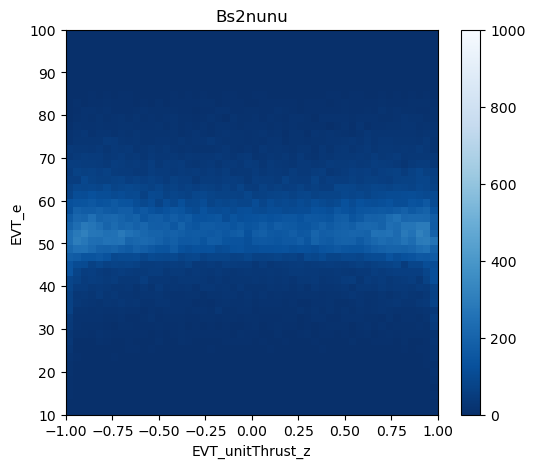

In [38]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

# Big bins
h=axs.hist2d(df_Bs_chunk0["EVT_unitThrust_z"], df_Bs_chunk0["EVT_e"], bins=(50, 50), range=[[-1, 1],[10, 100]], cmap=plt.cm.Blues_r,vmin=0,vmax=1000)
axs.set_title('Bs2nunu')
axs.set_ylabel('EVT_e')
axs.set_xlabel('EVT_unitThrust_z')
# Visualizing colorbar 
fig.colorbar(h[3], ax=axs)
plt.show()

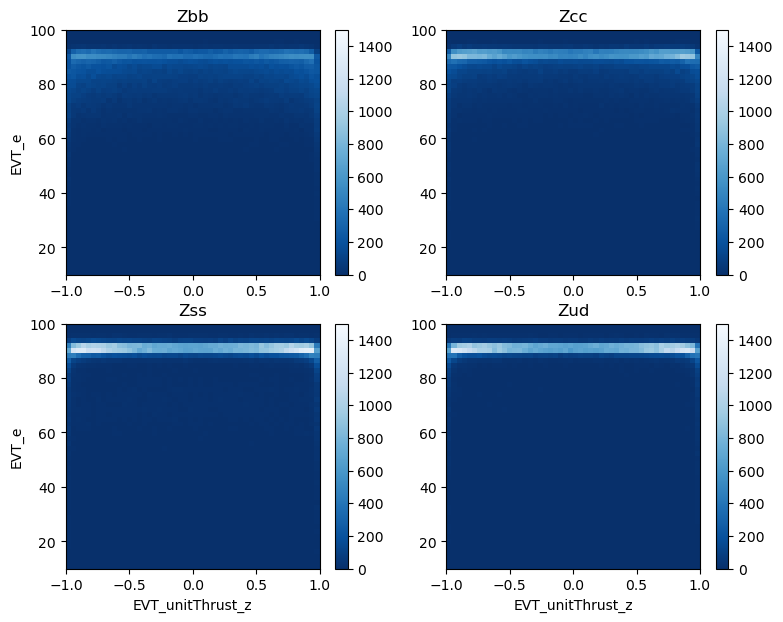

In [35]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('EVT_e')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_unitThrust_z')
axs[1,0].set_ylabel('EVT_e')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_unitThrust_z')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb["EVT_unitThrust_z"], df_bb["EVT_e"], bins=(50, 50), range=[[-1, 1],[10, 100]], cmap=plt.cm.Blues_r,vmin=0,vmax=1500)
h2 = axs[0, 1].hist2d(df_cc["EVT_unitThrust_z"], df_cc["EVT_e"], bins=(50, 50), range=[[-1, 1],[10, 100]], cmap=plt.cm.Blues_r,vmin=0,vmax=1500)
h3 = axs[1, 0].hist2d(df_ss["EVT_unitThrust_z"], df_ss["EVT_e"], bins=(50, 50), range=[[-1, 1],[10, 100]], cmap=plt.cm.Blues_r,vmin=0,vmax=1500)
h4 = axs[1, 1].hist2d(df_ud["EVT_unitThrust_z"], df_ud["EVT_e"], bins=(50, 50), range=[ [-1, 1],[10, 100]], cmap=plt.cm.Blues_r,vmin=0,vmax=1500)

# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])

plt.show()



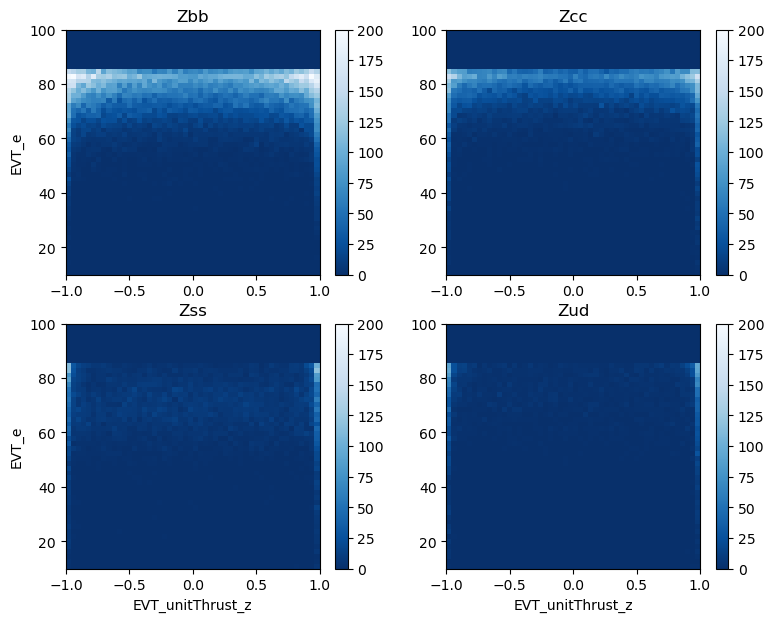

In [39]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('EVT_e')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_unitThrust_z')
axs[1,0].set_ylabel('EVT_e')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_unitThrust_z')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb_kp["EVT_unitThrust_z"], df_bb_kp["EVT_e"], bins=(50, 50), range=[[-1, 1],[10, 100]], cmap=plt.cm.Blues_r,vmin=0,vmax=200)
h2 = axs[0, 1].hist2d(df_cc_kp["EVT_unitThrust_z"], df_cc_kp["EVT_e"], bins=(50, 50), range=[[-1, 1],[10, 100]], cmap=plt.cm.Blues_r,vmin=0,vmax=200)
h3 = axs[1, 0].hist2d(df_ss_kp["EVT_unitThrust_z"], df_ss_kp["EVT_e"], bins=(50, 50), range=[[-1, 1],[10, 100]], cmap=plt.cm.Blues_r,vmin=0,vmax=200)
h4 = axs[1, 1].hist2d(df_ud_kp["EVT_unitThrust_z"], df_ud_kp["EVT_e"], bins=(50, 50), range=[ [-1, 1],[10, 100]], cmap=plt.cm.Blues_r,vmin=0,vmax=200)

# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])

plt.show()



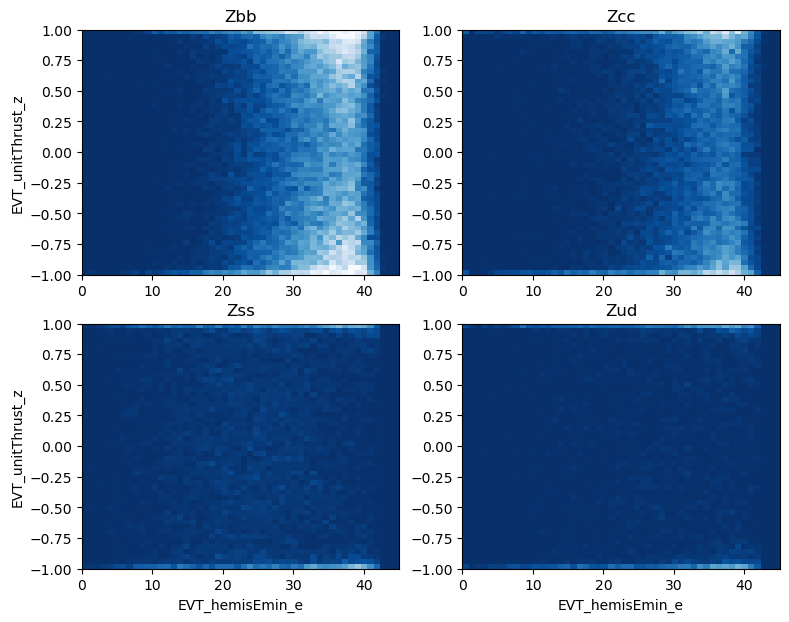

In [43]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('EVT_unitThrust_z')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_hemisEmin_e')
axs[1,0].set_ylabel('EVT_unitThrust_z')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_hemisEmin_e')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb_kp["EVT_hemisEmin_e"], df_bb_kp["EVT_unitThrust_z"], bins=(50, 50), range=[ [0, 45],[-1, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)
h2 = axs[0, 1].hist2d(df_cc_kp["EVT_hemisEmin_e"], df_cc_kp["EVT_unitThrust_z"], bins=(50, 50), range=[ [0, 45],[-1, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)
h3 = axs[1, 0].hist2d(df_ss_kp["EVT_hemisEmin_e"], df_ss_kp["EVT_unitThrust_z"], bins=(50, 50), range=[ [0, 45],[-1, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)
h4 = axs[1, 1].hist2d(df_ud_kp["EVT_hemisEmin_e"], df_ud_kp["EVT_unitThrust_z"], bins=(50, 50), range=[ [0, 45],[-1, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)


plt.show()



## Thrust_mag (ie. T) 2d plots

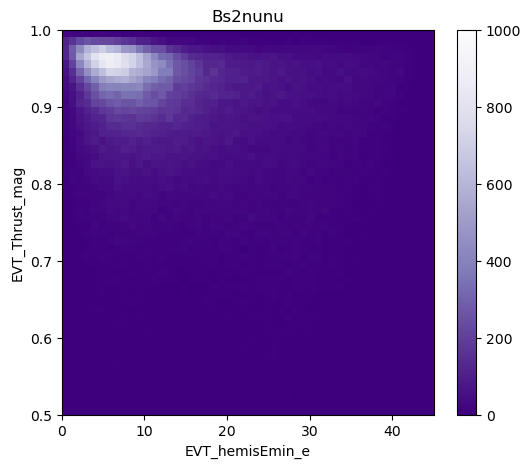

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

# Big bins
h=axs.hist2d(df_Bs_chunk0["EVT_hemisEmin_e"], df_Bs_chunk0["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)
axs.set_title('Bs2nunu')
axs.set_ylabel('EVT_Thrust_mag')
axs.set_xlabel('EVT_hemisEmin_e')

# Visualizing colorbar 
fig.colorbar(h[3], ax=axs)
plt.show()

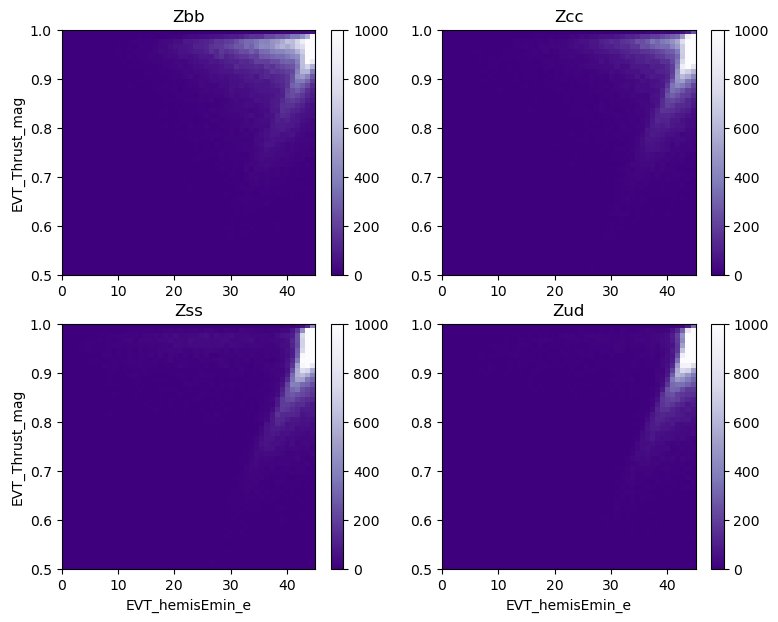

In [12]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('EVT_Thrust_mag')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_hemisEmin_e')
axs[1,0].set_ylabel('EVT_Thrust_mag')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_hemisEmin_e')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb["EVT_hemisEmin_e"], df_bb["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)
h2 = axs[0, 1].hist2d(df_cc["EVT_hemisEmin_e"], df_cc["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)
h3 = axs[1, 0].hist2d(df_ss["EVT_hemisEmin_e"], df_ss["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)
h4 = axs[1, 1].hist2d(df_ud["EVT_hemisEmin_e"], df_ud["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)


# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])


plt.show()



In [13]:
df_bb_rm = df_bb[df_bb["EVT_e"]>=85]
df_cc_rm = df_cc[df_cc["EVT_e"]>=85]
df_ss_rm = df_ss[df_ss["EVT_e"]>=85]
df_ud_rm = df_ud[df_ud["EVT_e"]>=85]


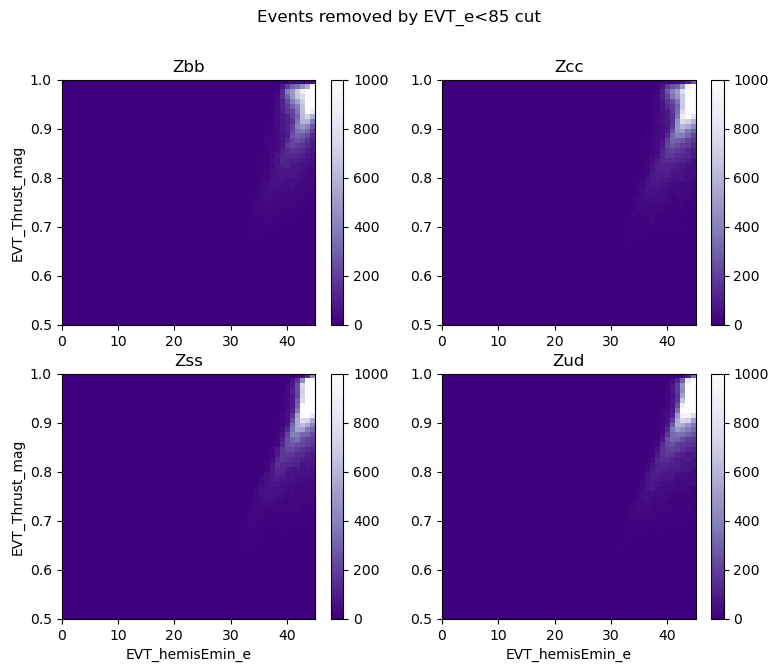

In [14]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('EVT_Thrust_mag')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_hemisEmin_e')
axs[1,0].set_ylabel('EVT_Thrust_mag')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_hemisEmin_e')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb_rm["EVT_hemisEmin_e"], df_bb_rm["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)
h2 = axs[0, 1].hist2d(df_cc_rm["EVT_hemisEmin_e"], df_cc_rm["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)
h3 = axs[1, 0].hist2d(df_ss_rm["EVT_hemisEmin_e"], df_ss_rm["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)
h4 = axs[1, 1].hist2d(df_ud_rm["EVT_hemisEmin_e"], df_ud_rm["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)


# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])

plt.suptitle('Events removed by EVT_e<85 cut')
plt.show()



In [15]:
df_bb_kp = df_bb[df_bb["EVT_e"]<85]
df_cc_kp = df_cc[df_cc["EVT_e"]<85]
df_ss_kp = df_ss[df_ss["EVT_e"]<85]
df_ud_kp = df_ud[df_ud["EVT_e"]<85]


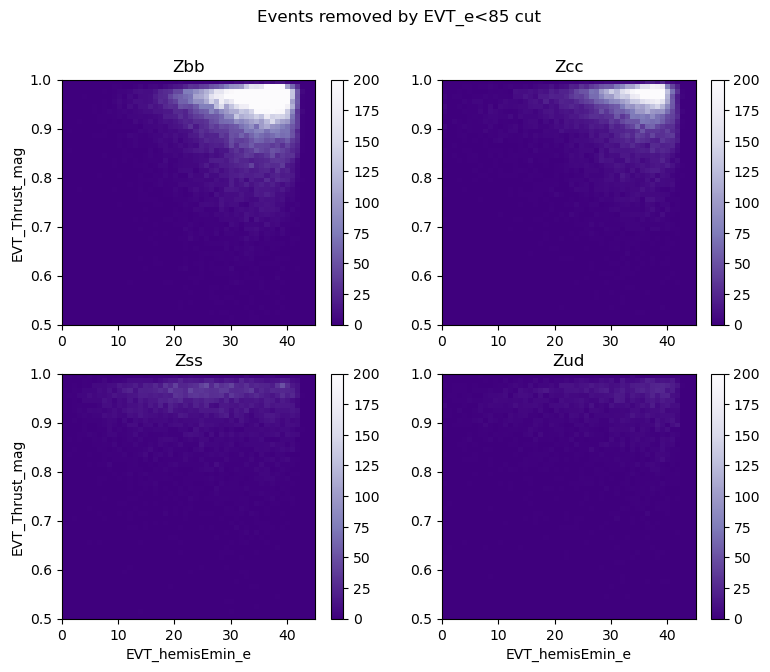

In [16]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('EVT_Thrust_mag')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_hemisEmin_e')
axs[1,0].set_ylabel('EVT_Thrust_mag')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_hemisEmin_e')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb_kp["EVT_hemisEmin_e"], df_bb_kp["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=200)
h2 = axs[0, 1].hist2d(df_cc_kp["EVT_hemisEmin_e"], df_cc_kp["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=200)
h3 = axs[1, 0].hist2d(df_ss_kp["EVT_hemisEmin_e"], df_ss_kp["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=200)
h4 = axs[1, 1].hist2d(df_ud_kp["EVT_hemisEmin_e"], df_ud_kp["EVT_Thrust_mag"], bins=(50, 50), range=[[0, 45],[0.5, 1]], cmap=plt.cm.Purples_r,vmin=0,vmax=200)


# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])

plt.suptitle('Events removed by EVT_e<85 cut')
plt.show()



## Thrust length 2d plots - am fairly sure no physical meaning

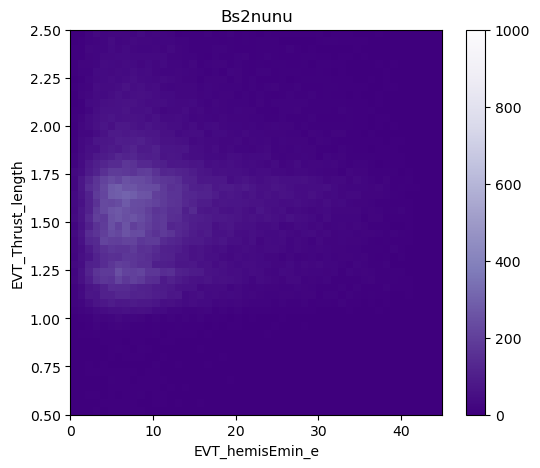

In [17]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

length = np.sqrt(df_Bs_chunk0["EVT_Thrust_x"]**2 + df_Bs_chunk0["EVT_Thrust_y"]**2+ df_Bs_chunk0["EVT_Thrust_z"]**2)

# Big bins
h=axs.hist2d(df_Bs_chunk0["EVT_hemisEmin_e"], length, bins=(50, 50), range=[[0, 45],[0.5, 2.5]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)
axs.set_title('Bs2nunu')
axs.set_ylabel('EVT_Thrust_length')
axs.set_xlabel('EVT_hemisEmin_e')

# Visualizing colorbar 
fig.colorbar(h[3], ax=axs)
plt.show()

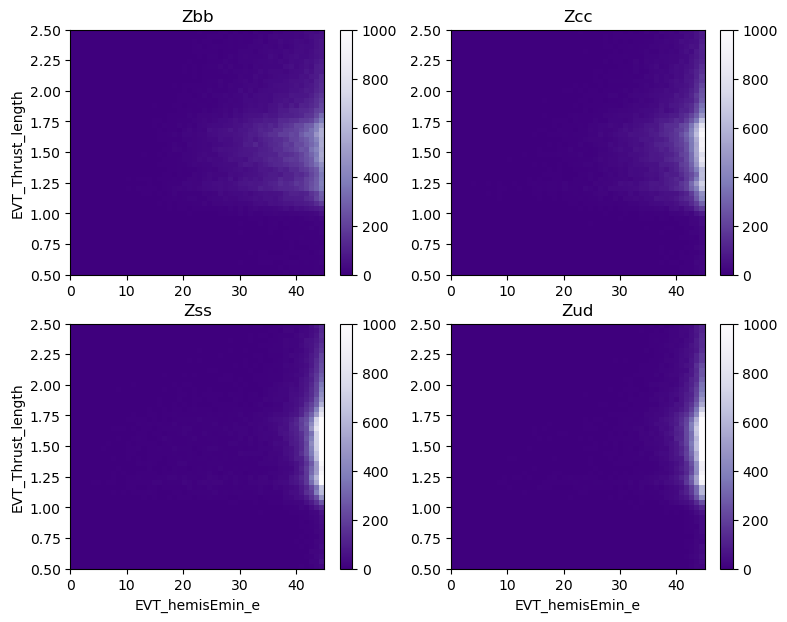

In [18]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('EVT_Thrust_length')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('EVT_hemisEmin_e')
axs[1,0].set_ylabel('EVT_Thrust_length')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('EVT_hemisEmin_e')
#axs[1, 1].set_yticklabels([])

lengthbb = np.sqrt(df_bb["EVT_Thrust_x"]**2 + df_bb["EVT_Thrust_y"]**2+ df_bb["EVT_Thrust_z"]**2)
lengthcc = np.sqrt(df_cc["EVT_Thrust_x"]**2 + df_cc["EVT_Thrust_y"]**2+ df_cc["EVT_Thrust_z"]**2)
lengthss = np.sqrt(df_ss["EVT_Thrust_x"]**2 + df_ss["EVT_Thrust_y"]**2+ df_ss["EVT_Thrust_z"]**2)
lengthud = np.sqrt(df_ud["EVT_Thrust_x"]**2 + df_ud["EVT_Thrust_y"]**2+ df_ud["EVT_Thrust_z"]**2)


h1 = axs[0, 0].hist2d(df_bb["EVT_hemisEmin_e"], lengthbb, bins=(50, 50), range=[[0, 45],[0.5, 2.5]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)
h2 = axs[0, 1].hist2d(df_cc["EVT_hemisEmin_e"], lengthcc, bins=(50, 50), range=[[0, 45],[0.5, 2.5]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)
h3 = axs[1, 0].hist2d(df_ss["EVT_hemisEmin_e"], lengthss, bins=(50, 50), range=[[0, 45],[0.5, 2.5]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)
h4 = axs[1, 1].hist2d(df_ud["EVT_hemisEmin_e"], lengthud, bins=(50, 50), range=[[0, 45],[0.5, 2.5]], cmap=plt.cm.Purples_r,vmin=0,vmax=1000)


# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])


plt.show()

